In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set(style="whitegrid")

In [3]:
# Chargement des données
cols_to_read = [
    "id",
    "conv_turns",
    "categories",
    "total_conv_a_output_tokens",
    "total_conv_b_output_tokens",
    "conversation_pair_id"
]

conversations = pd.read_parquet(
    "../data/comparia-conversations/conversations.parquet",
    columns=cols_to_read
)

cols_votes = [
    "conversation_pair_id",
    "chosen_model_name",
    "both_equal"
]

votes = pd.read_parquet(
    "../data/comparia-votes/votes.parquet",
    columns=cols_votes
)

print("Conversations:", conversations.shape)
print("Votes:", votes.shape)
print(conversations.columns)
print(votes.columns)

Conversations: (472334, 6)
Votes: (157132, 3)
Index(['id', 'conv_turns', 'categories', 'total_conv_a_output_tokens',
       'total_conv_b_output_tokens', 'conversation_pair_id'],
      dtype='str')
Index(['conversation_pair_id', 'chosen_model_name', 'both_equal'], dtype='str')


In [4]:
conversations["total_output_tokens"] = (
    conversations["total_conv_a_output_tokens"] + conversations["total_conv_b_output_tokens"]
)

## Conversations votées et non votées

In [5]:
voted_ids = votes["conversation_pair_id"].unique()
conversations["voted"] = conversations["conversation_pair_id"].isin(voted_ids)

print("Nombre total de conversations:", len(conversations))
print("Nombre de conversations votées:", conversations['voted'].sum())
print("Nombre de conversations non votées:", (~conversations['voted']).sum())

Nombre total de conversations: 472334
Nombre de conversations votées: 153062
Nombre de conversations non votées: 319272


## Comparaison des distributions

### Colonne : conv_turns

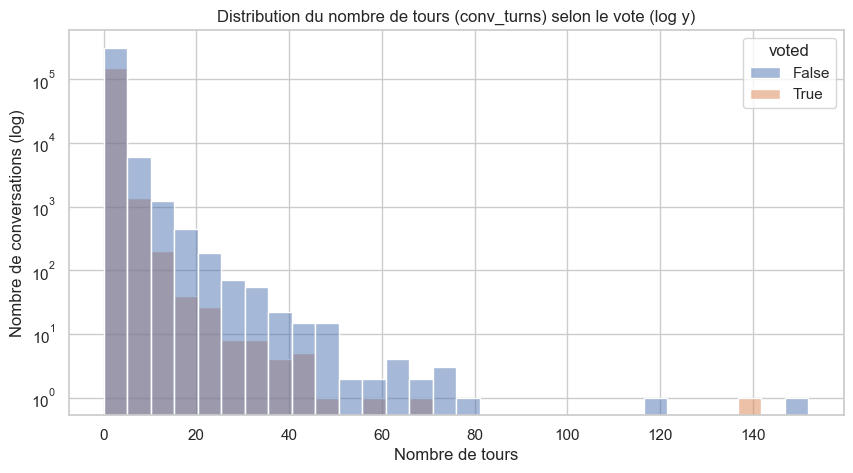

In [6]:
## conv_turns
plt.figure(figsize=(10,5))
sns.histplot(
    data=conversations,
    x='conv_turns',
    hue='voted',
    bins=30,
    kde=False,
    alpha=0.5
)
plt.yscale('log')
plt.title("Distribution du nombre de tours (conv_turns) selon le vote (log y)")
plt.xlabel("Nombre de tours")
plt.ylabel("Nombre de conversations (log)")
plt.show()

In [ ]:
# conv_turns : stats descriptives par voté
conv_turns_stats = (
    conversations.groupby('voted')['conv_turns']
    .agg(['count', 'mean', 'median', 'min', 'max', 'std'])
    .round(2)
)
print("Statistiques de conv_turns selon le vote :")
print(conv_turns_stats)

On observe que la distribution de conv-turns est quasi identique entre les votées et non votées, avec une légère tendance à plus de tours dans les conversations votées. Cependant, la différence n'est pas très marquée.
Il n'y a donc pas de biais significatif dans la longueur des conversations (en nombre de tours) entre celles qui sont votées et celles qui ne le sont pas.

### Colonne : total_output_tokens

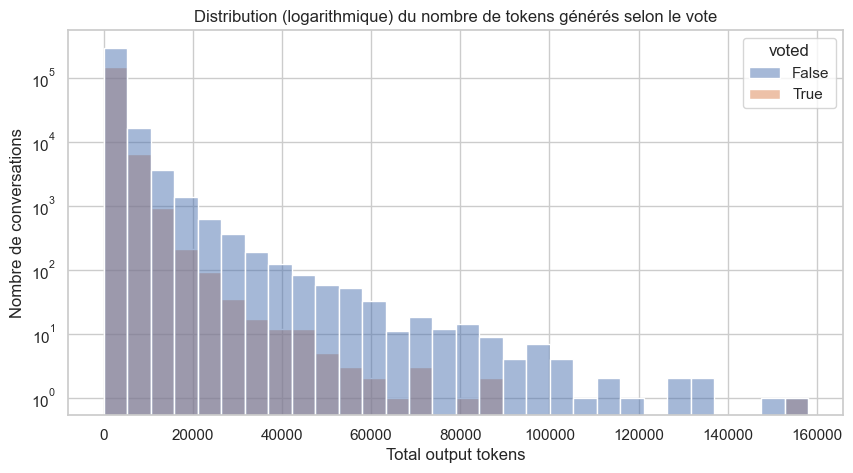

In [21]:
## total_output_tokens
plt.figure(figsize=(10,5))
sns.histplot(data=conversations, x='total_output_tokens', hue='voted', bins=30, kde=False, alpha=0.5)
plt.yscale('log')
plt.title("Distribution (logarithmique) du nombre de tokens générés selon le vote")
plt.xlabel("Total output tokens")
plt.ylabel("Nombre de conversations")
plt.show()

In [22]:
# total_output_tokens : stats descriptives par voté
tokens_stats = (
    conversations.groupby('voted')['total_output_tokens']
    .agg(['count', 'mean', 'median', 'min', 'max', 'std'])
    .round(2)
)
print("\nStatistiques de total_output_tokens selon le vote :")
print(tokens_stats)


Statistiques de total_output_tokens selon le vote :
        count     mean  median  min     max      std
voted                                               
False  319272  2005.45  1212.0    0  155841  3517.93
True   153062  2056.14  1554.0    0  158047  2193.44


On observe que les conversations votées sont globalement plus longues et les non votées contienne tbeaucoup plus de très petites conversations. 
Il y a donc un biais de sélection vers des conversations plus longues (en nombre de tokens générés) parmi celles qui sont votées, ce qui est cohérent avec l'idée que les utilisateurs ont tendance à voter pour des conversations plus riches et complètes.

### Colonne : categories

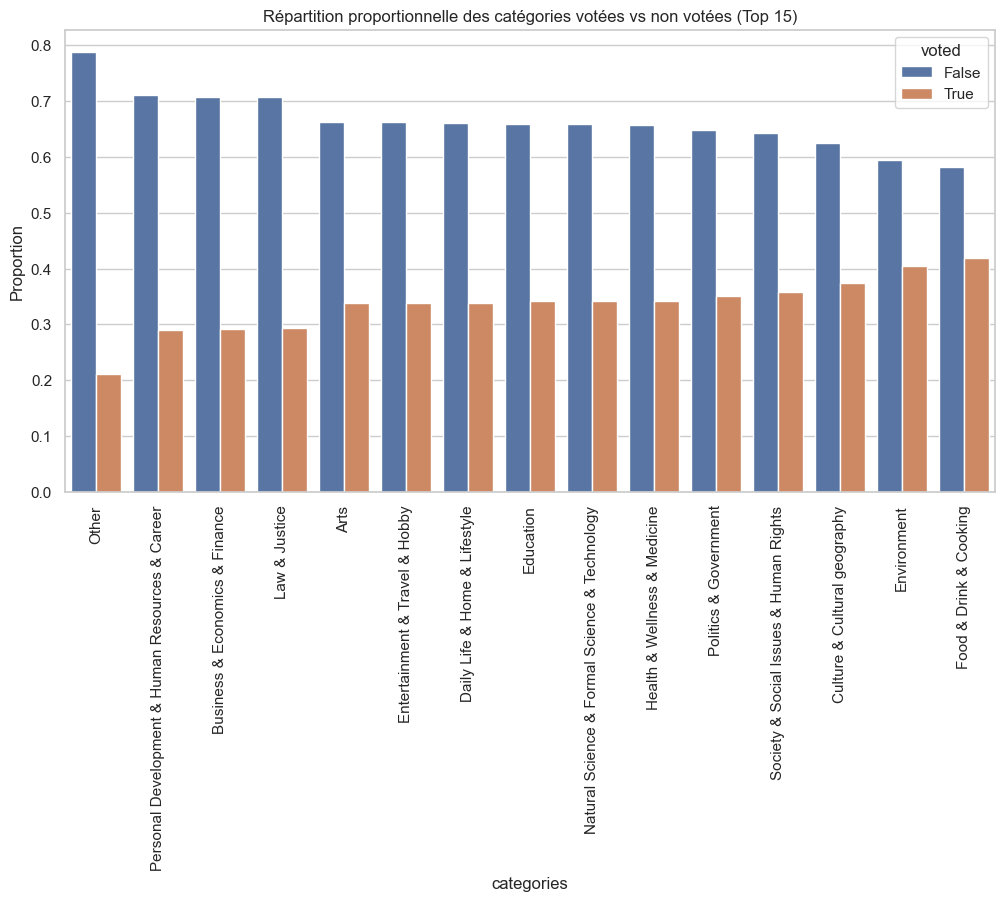

In [23]:
# exploser les catégories
conversations_exploded = conversations.explode('categories')

# supprimer les NA éventuels
conversations_exploded = conversations_exploded.dropna(subset=['categories'])

# agrégation
agg = (
    conversations_exploded
    .groupby(['categories', 'voted'])
    .size()
    .reset_index(name='count')
)

# garder les top 15 catégories par total conversations
top_categories = (
    agg.groupby('categories')['count']
    .sum()
    .nlargest(15)
    .index
)

agg = agg[agg['categories'].isin(top_categories)]

# s'assurer que toutes les combinaisons voté/non voté sont présentes
agg = agg.set_index(['categories', 'voted']).unstack(fill_value=0).stack().reset_index()

# calcul de la proportion par catégorie
agg['proportion'] = agg.groupby('categories')['count'].transform(lambda x: x / x.sum())

# ordre des catégories basé sur proportion de votées
order = (
    agg[agg['voted'] == False]
    .sort_values('proportion', ascending=False)['categories']
    .unique()
)

# plot
plt.figure(figsize=(12,6))
sns.barplot(data=agg, x='categories', y='proportion', hue='voted', order=order)
plt.xticks(rotation=90, ha='center')
plt.ylabel("Proportion")
plt.title("Répartition proportionnelle des catégories votées vs non votées (Top 15)")
plt.show()

In [24]:
# On ne garde que les votées
voted_prop = agg[agg['voted'] == True][['categories', 'proportion']]

# Trier par proportion croissante
voted_prop_sorted = voted_prop.sort_values('proportion', ascending=True)
least_voted = voted_prop_sorted.head(10)

least_voted['proportion_percent'] = (least_voted['proportion'] * 100).round(1)

print("Les catégories les moins votées proportionnellement au nombre de votes sont :\n")
print(least_voted[['categories', 'proportion_percent']])

Les catégories les moins votées proportionnellement au nombre de votes sont :

                                         categories  proportion_percent
23                                            Other                21.2
25  Personal Development & Human Resources & Career                29.0
3                    Business & Economics & Finance                29.2
19                                    Law & Justice                29.3
1                                              Arts                33.8
11                   Entertainment & Travel & Hobby                33.8
7                     Daily Life & Home & Lifestyle                33.9
9                                         Education                34.1
21    Natural Science & Formal Science & Technology                34.1
17                     Health & Wellness & Medicine                34.3


In [25]:
desc_stats = conversations.groupby('voted')[['conv_turns','total_output_tokens']].describe()
print(desc_stats)

      conv_turns                                                 \
           count      mean       std  min  25%  50%  75%    max   
voted                                                             
False   319272.0  1.384005  1.890506  0.0  1.0  1.0  1.0  152.0   
True    153062.0  1.339607  1.194428  0.0  1.0  1.0  1.0  140.0   

      total_output_tokens                                                \
                    count         mean          std  min    25%     50%   
voted                                                                     
False            319272.0  2005.448154  3517.934793  0.0  284.0  1212.0   
True             153062.0  2056.140218  2193.438911  0.0  919.0  1554.0   

                         
          75%       max  
voted                    
False  2394.0  155841.0  
True   2534.0  158047.0  


On observe que certaines catégories sont nettement moins votées et que le vote dépend probablement du type de contenu. 
Il y a donc un biais de représentation selon les catégories, avec une sous-représentation de certaines catégories dans les conversations votées.

## Conclusion

En résumé, les classements basés uniquement sur les votes ne reflètent pas parfaitement l’ensemble du corpus. Ils sont relativement fiables pour des aspects structurels comme le nombre de tours, mais ils sur-représentent certaines catégories et les conversations plus longues. 
Pour garantir une meilleure généralisabilité, il serait nécessaire de rééquilibrer le dataset ou de pondérer les votes en fonction des catégories et de la longueur des conversations.